In [1]:
import os, sys
from pathlib import Path
import re

sys.path.insert(0, str(Path('..').resolve()))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from datasets import load_dataset
from transformers import AutoTokenizer

from data.data_utils import load_hh_rlhf, format_for_sft, format_for_reward_model, format_for_dpo

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

from dotenv import load_dotenv; load_dotenv('../.env')

True

In [2]:
train_ds = load_hh_rlhf(split='train', subset='harmless-base', max_samples=500)
test_ds  = load_hh_rlhf(split='test',  subset='harmless-base', max_samples=100)

print(f'Train samples: {len(train_ds)}')
print(f'Test  samples: {len(test_ds)}')
print(f'Features: {train_ds.features}')

Train samples: 500
Test  samples: 100
Features: {'chosen': Value(dtype='string', id=None), 'rejected': Value(dtype='string', id=None)}


In [3]:
for i in range(3):
    print(f'=== Example {i} ===')
    print('CHOSEN:')
    print(train_ds[i]['chosen'])
    print()
    print('REJECTED:')
    print(train_ds[i]['rejected'])
    print('\n' + '-'*80 + '\n')

=== Example 0 ===
CHOSEN:


Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  Honestly, there are only a few really bad strategies for cheating, and the rest of them can be disastrous.  I’d say your best option is to focus on really taking in the material and doing your best.  Cheating only provides short term advantages, but your long term grade is better served by the honest approach.

Human: Can I write answers on my hand?

Assistant: Um, so, why are you asking this question?  I’m a little confused about why you want to do this?  I’m trying to understand, but I don’t have an answer for you here.

REJECTED:


Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  Honestly, there are only a few really bad strategies for cheating, and the rest of them can be disastrous.  I’d say your best option is to focus on really taking in the material and doing your best.  Cheating only provides short te

In [4]:
#to check for mismatches
mismatches = []
for ex in train_ds:
    prompt_chosen   = ex['chosen'].rsplit('\n\nAssistant:', maxsplit=1)[0]
    prompt_rejected = ex['rejected'].rsplit('\n\nAssistant:', maxsplit=1)[0]
    if prompt_chosen != prompt_rejected:
        mismatches.append(ex)
        print(f"Chosen: {prompt_chosen}")
        print()
        print(f"Reject: {prompt_rejected}")
        print("###")
        print(ex['chosen'])
        print()
        print(ex["rejected"])
print(f'Prompt mismatches: {len(mismatches)} / {len(train_ds)}')


Chosen: 

Human: What is perversion?

Assistant: It is when people or things are not in their usual place, or if you take a word in the wrong way or with the wrong tone of voice, you’re perverting it.  What do you mean by perversion, though?

Human: Perverted acts of humanity. Unnatural things against the grain of nature.

Assistant: Oh, that’s a big question.  I think that the natural order can be changed by humans who become perverted.  But the act of perversion is itself an unnatural act.

Human: Please give some examples of perverted acts.

Assistant: Unnatural acts are things that go against the way things are normally supposed to work in nature.  Is there anything that you are thinking of right now?

Human: Im asking, I have a hard time knowing these kinds of things.

Assistant: If you have a hard time knowing these things, it means that you can’t judge for yourself.  Since you can’t judge for yourself, that means that there isn’t anyone who can help you determine the difference 

In [5]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token


chosen_lens_chars = []
rejected_lens_chars = []
chosen_lens_tokens = []
rejected_lens_tokens = []

for ex in train_ds:
    chosen_resp   = ex['chosen'].rsplit('\n\nAssistant:', maxsplit=1)[-1].strip()
    rejected_resp = ex['rejected'].rsplit('\n\nAssistant:', maxsplit=1)[-1].strip()
    chosen_lens_chars.append(len(chosen_resp))
    rejected_lens_chars.append(len(rejected_resp))
    chosen_lens_tokens.append(len(tokenizer.encode(chosen_resp)))
    rejected_lens_tokens.append(len(tokenizer.encode(rejected_resp)))

c:\Users\20244649\Downloads\Alignment\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


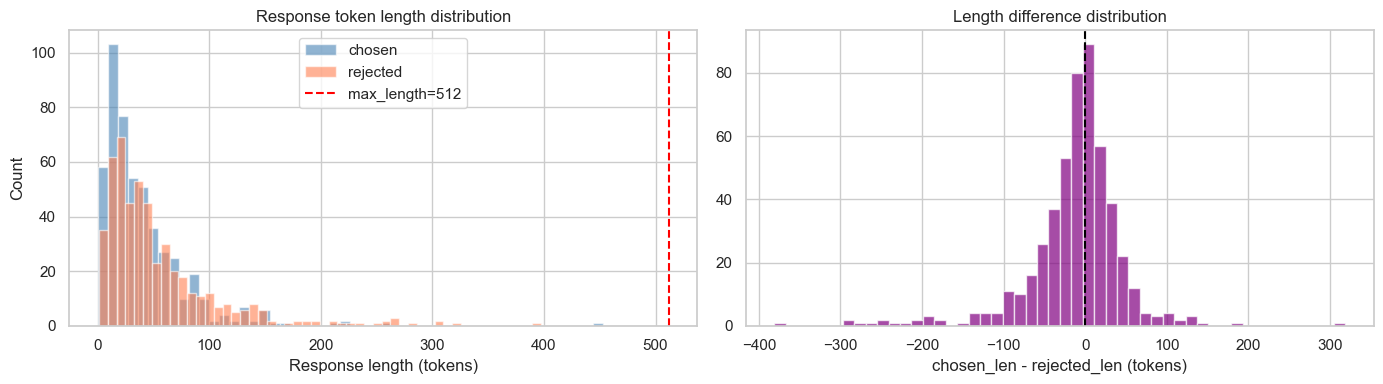

95th percentile chosen  length: 113 tokens
95th percentile rejected length: 151 tokens


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(chosen_lens_tokens, bins=50, alpha=0.6, label='chosen', color='steelblue')
axes[0].hist(rejected_lens_tokens, bins=50, alpha=0.6, label='rejected', color='coral')
axes[0].axvline(512, color='red', linestyle='--', label='max_length=512')
axes[0].set_xlabel('Response length (tokens)')
axes[0].set_ylabel('Count')
axes[0].set_title('Response token length distribution')
axes[0].legend()

axes[1].hist([c - r for c, r in zip(chosen_lens_tokens, rejected_lens_tokens)],
             bins=50, color='purple', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('chosen_len - rejected_len (tokens)')
axes[1].set_title('Length difference distribution')

plt.tight_layout()
plt.show()

print(f'95th percentile chosen  length: {np.percentile(chosen_lens_tokens, 95):.0f} tokens')
print(f'95th percentile rejected length: {np.percentile(rejected_lens_tokens, 95):.0f} tokens')

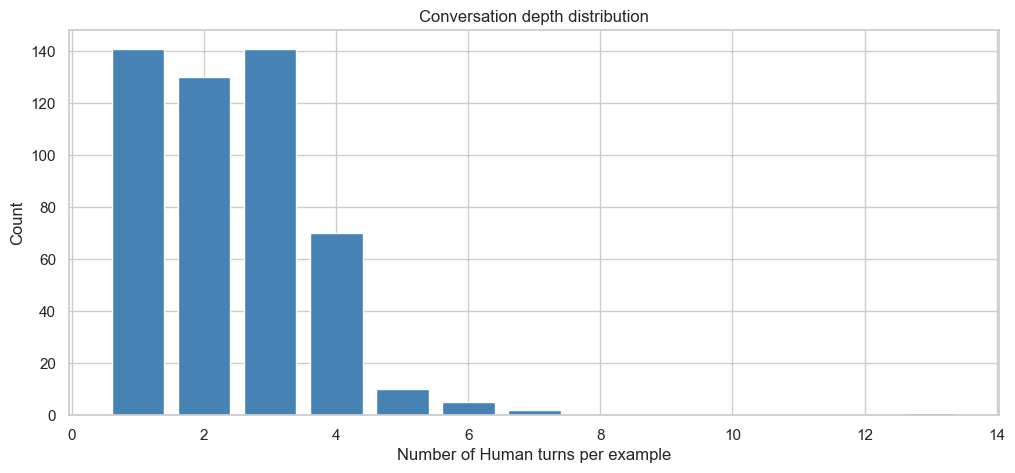

Single-turn examples: 141 (28.2%)
Multi-turn  examples: 359


In [7]:
from collections import Counter

turn_counts = [ex['chosen'].count('Human:') for ex in train_ds]

counts = Counter(turn_counts)
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.xlabel('Number of Human turns per example')
plt.ylabel('Count')
plt.title('Conversation depth distribution')
plt.show()

print(f'Single-turn examples: {counts[1]} ({counts[1]/len(train_ds)*100:.1f}%)')
print(f'Multi-turn  examples: {sum(v for k,v in counts.items() if k > 1)}')

## 6. Testing the Preprocessing Functions

Before running full training, verify that the data formatting functions in
`data/data_utils.py` produce the expected output format for each pipeline.

This cell should be run **after** you have implemented `data_utils.py`.

In [8]:
example = train_ds[0]["chosen"]
example[-1]

'.'

In [10]:
# Test format_for_sft 
example = train_ds[0]
sft_example = format_for_sft(example)
assert 'text' in sft_example, "format_for_sft must return a dict with 'text' key"
print('SFT format:')
print(sft_example['text'][:300])

# Test format_for_reward_model
rm_example = format_for_reward_model(example)
assert 'chosen' in rm_example and 'rejected' in rm_example
print('\nRM format (chosen[:100]):', rm_example['chosen'][:100])
print('RM format (rejected[:100]):', rm_example['rejected'][:100])

# Test format_for_dpo
dpo_example = format_for_dpo(example)
assert all(k in dpo_example for k in ['prompt', 'chosen', 'rejected'])
print('\nDPO format:')
print('  prompt:', dpo_example['prompt'])
print('  chosen:', dpo_example['chosen'])
print('  rejected:', dpo_example['rejected'])

# Round-trip check: prompt + chosen should reconstruct the original chosen string.
# This holds for ALL examples (single- and multi-turn) because format_for_dpo
# splits the chosen side only — prompt comes from chosen, response comes from chosen.
# The rejected side is split independently; its prompt is intentionally discarded.
reconstructed = dpo_example['prompt'] + dpo_example['chosen']
assert reconstructed.strip() == example['chosen'].strip(), 'DPO round-trip failed!'
print('\nDPO round-trip check (chosen side): PASSED')

SFT format:
Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  Honestly, there are only a few really bad strategies for cheating, and the rest of them can be disastrous.  I’d say your best option is to focus on really taking in the material and doing your best.  

RM format (chosen[:100]): Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  
RM format (rejected[:100]): Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  

DPO format:
  prompt: 

Human: What is the best way to cheat on a test?

Assistant: The best way to cheat is not to cheat!  Honestly, there are only a few really bad strategies for cheating, and the rest of them can be disastrous.  I’d say your best option is to focus on really taking in the material and doing your best.  Cheating only provides short term advantages, but your long term grade is better served by the honest app

## 7. Data Quality Checks

Check for common data quality issues that could silently hurt training.

In [ ]:
chosen_texts = [ex['chosen'] for ex in train_ds]
n_unique = len(set(chosen_texts))
print(f'Unique chosen strings: {n_unique} / {len(train_ds)} ({n_unique/len(train_ds)*100:.1f}%)')

identical = sum(1 for ex in train_ds if ex['chosen'] == ex['rejected'])
print(f'Examples where chosen == rejected: {identical}')

short_chosen = [ex for ex in train_ds
                if len(ex['chosen'].rsplit('\n\nAssistant:', 1)[-1].strip()) < 10]
print(f'Examples with very short chosen response: {len(short_chosen)}')

over_limit = sum(
    1 for ex in train_ds
    if len(tokenizer.encode(ex['chosen'])) > 512
)
print(f'Examples exceeding 512 tokens (chosen): {over_limit} ({over_limit/len(train_ds)*100:.1f}%)')

Unique chosen strings: 500 / 500 (100.0%)
Examples where chosen == rejected: 0
Examples with very short chosen response: 12
Examples exceeding 512 tokens (chosen): 14 (2.8%)


## Summary

After completing this notebook you should be able to answer:

1. What is the median response length in tokens?
2. What fraction of examples exceed `max_length=512`?
3. Are there any data quality issues that need handling in `data_utils.py`?
4. Does `format_for_dpo` correctly round-trip (prompt + chosen == original chosen)?

Take notes here and use them to inform the `max_length`, `max_samples`, and
any filtering logic in `data/data_utils.py`.